# RR Lyrae Period Measurement — Rubin Data Preview 2 × VSX
---
This notebook measures pulsation periods for **100 RR Lyrae stars** by:

1. Querying the [VSX catalog](https://www.aavso.org/vsx/) (via VizieR) for confirmed RR Lyrae with known periods  
2. Cross-matching positions with **Rubin DP2** forced-source photometry through the RSP TAP service  
3. Running **Lomb-Scargle** period analysis (`astropy.timeseries.LombScargle`)  
4. Comparing recovered periods against the VSX reference values  

### Prerequisites
```bash
pip install astropy astroquery pyvo pandas numpy matplotlib
```

### Authentication
A **Rubin Science Platform token** is required.  
Obtain one at <https://data.lsst.cloud> after registering for DP2 access, then either:
- set `RUBIN_RSP_TOKEN` in your environment, **or**
- paste it into the `RSP_TOKEN` cell below.

> **DP2 sky footprint:** RA 55–75°, Dec −44° to −27° (DC2 simulated survey area).  
> VSX stars outside this region will not return light curves and are skipped gracefully.

## 0 · Imports & notebook settings

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from IPython.display import display

from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.timeseries import LombScargle

from astroquery.vizier import Vizier
import pyvo

warnings.filterwarnings("ignore")

# Inline plots, publication-quality defaults
%matplotlib inline
plt.rcParams.update({
    "figure.dpi"      : 120,
    "axes.grid"       : True,
    "grid.alpha"      : 0.3,
    "font.size"       : 11,
    "axes.labelsize"  : 12,
    "axes.titlesize"  : 12,
})
print("Imports OK ✓")

Imports OK ✓


## 1 · Configuration

Adjust the parameters below to change the sample size, search radius, or period grid.

In [2]:
# ── User settings ──────────────────────────────────────────────────────────────
RSP_TOKEN        = ""          # ← paste token here, or leave "" to read from env

N_STARS          = 100         # RR Lyrae to retrieve from VSX
MIN_EPOCHS       = 20          # minimum light-curve points to attempt period fit
XMATCH_RADIUS    = 1.0         # cross-match radius (arcsec)
LS_FAP_THRESHOLD = 0.01        # false-alarm probability cut for "significant" detection

PERIOD_MIN       = 0.2         # days  — shortest period to search
PERIOD_MAX       = 1.0         # days  — longest  period to search

PLOT_N           = 10          # number of phase-folded light curves to display
OUTPUT_DIR       = Path("rr_lyrae_output")

# ── Fixed constants ─────────────────────────────────────────────────────────────
RSP_TAP_URL  = "https://data.lsst.cloud/api/tap"
VSX_CATALOG  = "B/vsx/vsx"
BAND_PREF    = ["r", "i", "g"]   # band preference order for period fitting

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Output directory: /home/b/brantd/notebooks_lf/sprints/2026/03_12/homework_4/rr_lyrae_output


## 2 · Authenticate with the Rubin Science Platform

We use `pyvo` with bearer-token authentication to reach the DP2 TAP service.

In [3]:
def get_tap_service(token: str = "") -> pyvo.dal.TAPService:
    """Return an authenticated TAP service for the Rubin RSP."""
    token = token or os.environ.get("RUBIN_RSP_TOKEN", "")
    if not token:
        raise EnvironmentError(
            "RSP token not found.\n"
            "Set RSP_TOKEN above, or export RUBIN_RSP_TOKEN in your shell."
        )
    cred = pyvo.auth.CredentialStore()
    cred.set_password("x-oauth-basic", token)
    session = pyvo.auth.AuthSession()
    session.credentials = cred
    session.add_security_method_for_url(RSP_TAP_URL, "bearer")
    return pyvo.dal.TAPService(RSP_TAP_URL, session=session)

tap = get_tap_service(RSP_TOKEN)
print("TAP service ready ✓")

OSError: RSP token not found.
Set RSP_TOKEN above, or export RUBIN_RSP_TOKEN in your shell.

## 3 · Query VSX for RR Lyrae

We query the AAVSO International Variable Star Index (VSX) via VizieR for confirmed  
RR Lyrae (types RRAB, RRC, RRD, …) that have a published period.  
These catalog periods serve as ground truth for validating our LS recovery.

In [4]:
def fetch_vsx_rr_lyrae(n: int = N_STARS) -> Table:
    """Fetch n RR Lyrae with known periods from VSX via VizieR."""
    viz = Vizier(
        columns=["OID", "Name", "RAJ2000", "DEJ2000", "Type", "Period", "max", "min"],
        row_limit=n * 2,
    )
    result = viz.query_constraints(catalog=VSX_CATALOG, Type="RR*")
    if not result:
        raise RuntimeError("VSX query returned no results.")

    tbl = result[0]
    rr_mask    = np.array([str(t).strip().startswith("RR") for t in tbl["Type"]])
    has_period = (~tbl["Period"].mask
                  if hasattr(tbl["Period"], "mask")
                  else np.ones(len(tbl), bool))
    tbl = tbl[rr_mask & has_period][:n]
    return tbl

vsx_table = fetch_vsx_rr_lyrae()
print(f"Retrieved {len(vsx_table)} RR Lyrae from VSX")
vsx_table[["OID", "Name", "RAJ2000", "DEJ2000", "Type", "Period"]].to_pandas().head(10)

Retrieved 100 RR Lyrae from VSX


,OID,Name,RAJ2000,DEJ2000,Type,Period
0,8699932,Gaia DR3 429519617490941312,0.01002,61.61774,RRAB,0.437408
1,8699933,Gaia DR3 4702976338577905536,0.01245,-70.24083,RRAB,0.630570
2,672783,PS1-3PI J000003.12-022548.2,0.01307,-2.43007,RRAB,0.493647
3,195,GM And,0.01521,35.36286,RRAB,0.706758
4,8699935,Gaia DR3 431630714178285568,0.01630,63.88569,RRC,0.273500
5,287959,CSS_J000004.0+182425,0.01669,18.40698,RRAB,0.485160
6,8699936,Gaia DR3 2416047678141001216,0.02738,-15.49816,RRAB,0.525930
7,251805,V1023 Cas,0.02771,56.65331,RRAB,0.643700
8,8699938,Gaia DR3 2875547022047451264,0.03163,35.58506,RRC,0.361731
9,477711,SERIV 27,0.03171,34.67397,RRAB,0.461959


### VSX period distribution

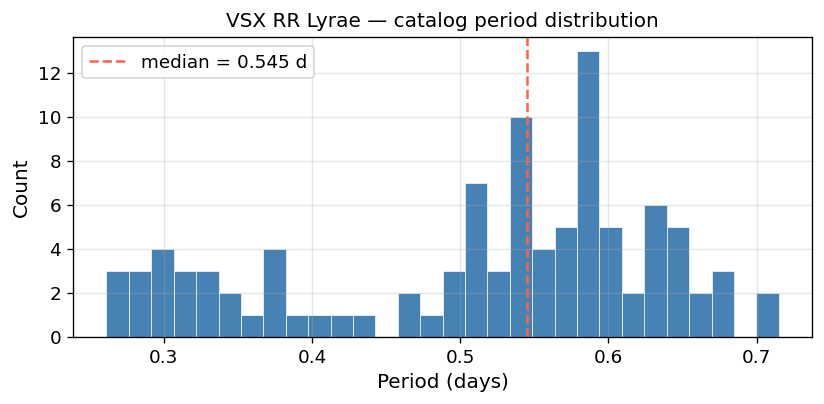

In [5]:
periods_vsx = vsx_table["Period"].data.data.astype(float)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(periods_vsx, bins=30, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(np.median(periods_vsx), color="tomato", ls="--", label=f"median = {np.median(periods_vsx):.3f} d")
ax.set_xlabel("Period (days)")
ax.set_ylabel("Count")
ax.set_title("VSX RR Lyrae — catalog period distribution")
ax.legend()
plt.tight_layout()

## 4 · Retrieve DP2 Light Curves via TAP

For each VSX star we issue an ADQL cone-search against  
`dp02_dc2_catalogs.ForcedSourceOnDiaObject` (g / r / i bands, PSF photometry).  
Stars with fewer than `MIN_EPOCHS` observations are skipped.

In [6]:
def build_adql_lightcurve(ra: float, dec: float,
                           radius_arcsec: float = XMATCH_RADIUS) -> str:
    r = radius_arcsec / 3600.0
    return f"""
    SELECT
        fsrc.diaObjectId,
        fsrc.midpointMjdTai  AS mjd,
        fsrc.psfFlux         AS flux,
        fsrc.psfFluxErr      AS flux_err,
        fsrc.band
    FROM
        dp02_dc2_catalogs.ForcedSourceOnDiaObject AS fsrc
        JOIN dp02_dc2_catalogs.DiaObject          AS obj
            ON fsrc.diaObjectId = obj.diaObjectId
    WHERE
        CONTAINS(
            POINT('ICRS', obj.ra, obj.dec),
            CIRCLE('ICRS', {ra}, {dec}, {r})
        ) = 1
        AND fsrc.band       IN ('g', 'r', 'i')
        AND fsrc.psfFlux    IS NOT NULL
        AND fsrc.psfFluxErr IS NOT NULL
        AND fsrc.psfFluxErr > 0
    ORDER BY fsrc.midpointMjdTai
    """


def fetch_lightcurves(tap, vsx_table) -> dict:
    """Fetch DP2 photometry for each VSX star. Returns {oid: DataFrame}."""
    lcs, n = {}, len(vsx_table)
    for i, row in enumerate(vsx_table):
        oid = str(row["OID"])
        ra, dec = float(row["RAJ2000"]), float(row["DEJ2000"])
        print(f"  [{i+1:3d}/{n}] OID {oid:>10s}  RA={ra:9.4f}  Dec={dec:+9.4f} … ",
              end="", flush=True)
        try:
            df = tap.search(build_adql_lightcurve(ra, dec)).to_table().to_pandas()
        except Exception as exc:
            print(f"ERROR: {exc}")
            continue
        if len(df) < MIN_EPOCHS:
            print(f"only {len(df)} epochs — skip")
            continue
        print(f"{len(df)} epochs ✓")
        lcs[oid] = df
    print(f"\nLight curves: {len(lcs)} / {n} stars with ≥{MIN_EPOCHS} epochs")
    return lcs

lightcurves = fetch_lightcurves(tap, vsx_table)

NameError: name 'tap' is not defined

### Epoch counts per star

In [ ]:
epoch_counts = {oid: len(df) for oid, df in lightcurves.items()}

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(epoch_counts)), sorted(epoch_counts.values(), reverse=True),
       color="steelblue", width=1.0)
ax.set_xlabel("Star rank (sorted by epoch count)")
ax.set_ylabel("Number of epochs")
ax.set_title(f"DP2 epoch counts — {len(epoch_counts)} stars retrieved")
plt.tight_layout()

## 5 · Lomb-Scargle Period Measurement

We convert PSF fluxes to AB magnitudes, then run `LombScargle.autopower()`  
searching 0.2 – 1.0 days (the canonical RR Lyrae range).  
Band preference order: **r → i → g** (whichever has ≥ `MIN_EPOCHS` points).

In [ ]:
def flux_to_mag(flux, flux_err, zp=3631.0):
    """AB magnitude conversion from linear flux (nJy or Jy — units cancel in ratio)."""
    with np.errstate(divide="ignore", invalid="ignore"):
        mag     = -2.5 * np.log10(flux / zp)
        mag_err = (2.5 / np.log(10)) * np.abs(flux_err / flux)
    return mag, mag_err


def measure_period(df: pd.DataFrame) -> dict:
    """Run LS on the best-populated single band. Returns result dict or {}."""
    for band in BAND_PREF:
        sub = df[df["band"] == band].dropna(subset=["mjd", "flux", "flux_err"])
        sub = sub[sub["flux"] > 0]
        if len(sub) >= MIN_EPOCHS:
            break
    else:
        return {}

    t, flux, flux_err = sub["mjd"].values, sub["flux"].values, sub["flux_err"].values
    mag, mag_err = flux_to_mag(flux, flux_err)
    ok = np.isfinite(mag) & np.isfinite(mag_err) & (mag_err > 0)
    t, mag, mag_err = t[ok], mag[ok], mag_err[ok]
    if len(t) < MIN_EPOCHS:
        return {}

    ls   = LombScargle(t, mag, mag_err)
    freq, power = ls.autopower(
        minimum_frequency=1.0 / PERIOD_MAX,
        maximum_frequency=1.0 / PERIOD_MIN,
        samples_per_peak=10,
    )
    best_freq   = freq[np.argmax(power)]
    best_period = 1.0 / best_freq
    fap         = ls.false_alarm_probability(power.max())

    return dict(
        period_days=best_period, power=float(power.max()), fap=float(fap),
        band=band, n_epochs=len(t),
        freq=freq, ls_power=power,
        t=t, mag=mag, mag_err=mag_err,
    )

In [ ]:
# Build VSX period lookup
vsx_period_map = {
    str(r["OID"]): float(r["Period"])
    for r in vsx_table
    if not (hasattr(r["Period"], "mask") and r["Period"].mask)
}

records = []
for oid, df in lightcurves.items():
    res = measure_period(df)
    if not res:
        continue
    records.append(dict(
        oid        = oid,
        period_ls  = res["period_days"],
        period_vsx = vsx_period_map.get(oid, np.nan),
        ls_power   = res["power"],
        ls_fap     = res["fap"],
        band       = res["band"],
        n_epochs   = res["n_epochs"],
        # keep raw arrays for plotting
        freq       = res["freq"],
        ls_pw      = res["ls_power"],
        t          = res["t"],
        mag        = res["mag"],
        mag_err    = res["mag_err"],
    ))

results = pd.DataFrame(records)
print(f"Period measurements: {len(results)} stars")
results[["oid","period_ls","period_vsx","ls_fap","band","n_epochs"]].head(10)

## 6 · Inspect Individual Periodograms

A quick sanity-check: plot the LS power spectrum for a handful of stars,  
marking the recovered period and (where available) the VSX reference period.

In [ ]:
n_show = min(6, len(results))
fig, axes = plt.subplots(n_show, 1, figsize=(10, 2.8 * n_show), sharex=False)
if n_show == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, results.head(n_show).iterrows()):
    period_grid = 1.0 / row["freq"]
    ax.plot(period_grid, row["ls_pw"], lw=0.8, color="steelblue")
    ax.axvline(row["period_ls"], color="tomato", lw=1.5,
               label=f"LS best = {row['period_ls']:.4f} d")
    if not np.isnan(row["period_vsx"]):
        ax.axvline(row["period_vsx"], color="gold", lw=1.5, ls="--",
                   label=f"VSX = {row['period_vsx']:.4f} d")
    ax.set_xlim(PERIOD_MIN, PERIOD_MAX)
    ax.set_ylabel("LS Power")
    ax.set_title(f"OID {row['oid']}  ({row['band']}-band,  {row['n_epochs']} pts,  "
                 f"FAP={row['ls_fap']:.2e})")
    ax.legend(fontsize=9, loc="upper right")

axes[-1].set_xlabel("Period (days)")
fig.suptitle("Lomb-Scargle Periodograms — first 6 stars", fontsize=13, y=1.01)
plt.tight_layout()

## 7 · Phase-Folded Light Curves

Each light curve is folded at the LS-recovered period and plotted twice  
(phase 0 – 2) so the sawtooth RR Lyrae shape is easy to see.

In [ ]:
n_show = min(PLOT_N, len(results))
ncols  = 2
nrows  = int(np.ceil(n_show / ncols))

fig = plt.figure(figsize=(13, 3.4 * nrows))
gs  = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.55, wspace=0.35)

band_colors = {"g": "#4daf4a", "r": "#e41a1c", "i": "#984ea3"}

for idx, (_, row) in enumerate(results.head(n_show).iterrows()):
    P     = row["period_ls"]
    phase = (row["t"] % P) / P
    order = np.argsort(phase)
    color = band_colors.get(row["band"], "steelblue")

    ax = fig.add_subplot(gs[idx // ncols, idx % ncols])
    for offset in (0, 1):
        ax.errorbar(
            phase[order] + offset,
            row["mag"][order],
            yerr=row["mag_err"][order],
            fmt=".", ms=3, elinewidth=0.5, color=color, alpha=0.65,
        )
    ax.invert_yaxis()
    ax.set_xlim(0, 2)
    ax.set_xlabel("Phase")
    ax.set_ylabel(f"{row['band']} [mag]")
    vsx_str = f"  (VSX {row['period_vsx']:.4f} d)" if not np.isnan(row['period_vsx']) else ""
    ax.set_title(f"OID {row['oid']}\nP = {P:.4f} d{vsx_str}", fontsize=10)

fig.suptitle("Phase-Folded RR Lyrae Light Curves — Rubin DP2", fontsize=13)
plt.tight_layout()

## 8 · LS vs VSX Period Comparison

A 1:1 scatter plot comparing the Lomb-Scargle recovered period against  
the VSX catalog period. Points on the dashed line are perfect recoveries;  
points near half or double the true period indicate aliasing.

In [ ]:
sub = results.dropna(subset=["period_vsx"]).copy()
sub["delta_P"] = sub["period_ls"] - sub["period_vsx"]
sub["good"]    = sub["ls_fap"] < LS_FAP_THRESHOLD

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── left: scatter ────────────────────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(
    sub["period_vsx"], sub["period_ls"],
    c=np.log10(sub["ls_fap"].clip(1e-20, 1)),
    cmap="viridis_r", s=30, edgecolors="k", linewidths=0.3, alpha=0.85,
)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("log₁₀(FAP)")
lim = [PERIOD_MIN - 0.02, PERIOD_MAX + 0.02]
ax.plot(lim, lim, "k--", lw=1, label="1:1")
ax.plot(lim, [x / 2 for x in lim], ":", color="tomato", lw=1, label="½ × P")
ax.plot(lim, [x * 2 for x in lim], ":", color="steelblue", lw=1, label="2 × P")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("VSX Period (days)")
ax.set_ylabel("LS Period (days)")
ax.set_title("Period recovery: LS vs VSX")
ax.legend(fontsize=9)

# ── right: residual histogram ─────────────────────────────────────────────────
ax2 = axes[1]
ax2.hist(sub["delta_P"], bins=25, color="steelblue", edgecolor="white", linewidth=0.4)
ax2.axvline(0, color="k", lw=1, ls="--")
ax2.axvline(sub["delta_P"].median(), color="tomato", lw=1.5, ls="--",
            label=f"median Δ = {sub['delta_P'].median():.4f} d")
ax2.set_xlabel("ΔP = P_LS − P_VSX (days)")
ax2.set_ylabel("Count")
ax2.set_title("Period residuals")
ax2.legend()

plt.suptitle("Lomb-Scargle Period Recovery — Rubin DP2 RR Lyrae", fontsize=13)
plt.tight_layout()

## 9 · Summary Statistics

In [ ]:
n_sig   = (results["ls_fap"] < LS_FAP_THRESHOLD).sum()
n_match = sub[sub["good"] & (sub["delta_P"].abs() < 0.01)].shape[0]  # within 0.01 d

print(f"{'Stars with light curves':.<45s} {len(lightcurves)}")
print(f"{'Stars with LS measurement':.<45s} {len(results)}")
print(f"{'Significant detections (FAP < {:.0e})'.format(LS_FAP_THRESHOLD):.<45s} {n_sig}")
if len(sub):
    print(f"{'Compared to VSX':.<45s} {len(sub)}")
    print(f"{'Period match within 0.01 d (FAP-significant)':.<45s} {n_match}")
    print(f"{'Median |ΔP|':.<45s} {sub['delta_P'].abs().median():.5f} d")
    print(f"{'RMS ΔP':.<45s} {sub['delta_P'].std():.5f} d")

print()
display(results[["oid","period_ls","period_vsx","ls_fap","band","n_epochs"]]
        .sort_values("ls_fap")
        .reset_index(drop=True)
        .style
        .format({"period_ls":"{:.5f}", "period_vsx":"{:.5f}", "ls_fap":"{:.2e}"})
        .background_gradient(subset="ls_fap", cmap="RdYlGn_r")
        .set_caption("RR Lyrae — Lomb-Scargle periods (sorted by FAP)")
)

## 10 · Save Results

In [ ]:
csv_path = OUTPUT_DIR / "rr_lyrae_periods.csv"
cols     = ["oid", "period_ls", "period_vsx", "ls_power", "ls_fap", "band", "n_epochs"]
results[cols].to_csv(csv_path, index=False)
print(f"Results saved → {csv_path}")

# Also save the comparison figure
fig_path = OUTPUT_DIR / "period_comparison.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Figure saved  → {fig_path}")